<h1 style="color: #f686bd">Aprendizado Supervisionado Prático com Scikit-Learn</h1>

**Autor(a):** Carolina Nascimento

**Data:** 13/03/26

**Objetivo:** Neste notebook, vamos aplicar os conceitos de **Regressão** e **Classificação** que aprendemos na teoria usando a biblioteca de Machine Learning em Python: a `scikit-learn` (ou apenas `sklearn`). Vamos usar a nossa base de dados `07_online_learning_engagement_dataset.csv` dados sintéticos que representam o envolvimento e o comportamento de aprendizagem dos alunos em um ambiente de educação online. Inclui diversas características relacionadas a dados demográficos dos alunos, hábitos de estudo, atividade na plataforma e desempenho acadêmico. Nosso objetivo será criar dois modelos:
1. **Regressão:** Prever a nota que o aluno vai tirar na prova final (`Nota_na_Prova`).
2. **Classificação:** Prever se o aluno irá **abandonar** ou não o curso.

In [12]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# Ferramentas do Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

## 1. Carregando e Preparando os Dados</h3>
 base de dados retirada de: [data](https://www.kaggle.com/datasets/ssssws/online-learning-engagement-dataset)

In [13]:
# Carregando os dados
df = pd.read_csv('data/07_online_learning_engagement_dataset.csv')
display(df.head(10))

,student_id,age,gender,country,device_type,internet_speed_mbps,study_hours_weekly,login_frequency_weekly,avg_session_duration_min,video_watch_time_min,assignments_submitted,forum_posts,quiz_attempts,avg_quiz_score,attendance_rate,engagement_score,final_grade,dropout
0,1,24,Female,USA,Laptop,44.70,15.92,10,40.052752,294.099759,3,4,6,46.69,0.93,8.046499,22.447641,0
1,2,37,Female,Germany,Tablet,61.10,6.37,8,32.442671,400.397658,7,14,5,62.65,0.59,6.312988,39.749905,1
2,3,46,Female,Australia,Tablet,43.10,6.64,7,43.614509,190.239738,1,14,5,58.42,0.43,4.143199,31.061688,1
3,4,32,Male,India,Tablet,26.99,10.91,5,30.697263,370.451629,3,1,2,61.21,0.65,6.125258,41.300634,0
4,5,28,Male,India,Laptop,52.28,7.41,6,47.402999,151.341296,4,4,6,74.92,0.55,4.979706,39.148998,1
5,6,25,Male,USA,Laptop,56.32,12.24,12,64.259993,281.288487,1,5,4,39.03,0.43,6.078442,20.239899,1
6,7,46,Female,USA,Mobile,52.62,4.78,12,61.482269,402.537310,8,4,4,94.95,0.85,5.846687,45.902425,0
7,8,38,Female,Germany,Mobile,39.38,11.51,13,30.064148,292.959149,3,2,5,73.43,0.50,6.517796,32.161525,1
8,9,24,Male,Canada,Mobile,83.62,3.98,5,36.850107,176.410108,9,7,7,58.96,0.45,5.276051,33.883459,1
9,10,43,Male,India,Mobile,57.90,13.04,12,51.732781,442.976482,9,14,3,70.69,0.57,8.526882,36.157768,1


In [14]:
# Dicionário de renomeação das colunas para português brasileiro
mapa_colunas = {
    'student_id': 'id_aluno',
    'age': 'idade',
    'gender': 'genero',
    'country': 'pais',
    'device_type': 'tipo_dispositivo',
    'internet_speed_mbps': 'velocidade_internet_mbps',
    'study_hours_weekly': 'horas_estudo_semanais',
    'login_frequency_weekly': 'frequencia_login_semanal',
    'avg_session_duration_min': 'duracao_media_sessao_min',
    'video_watch_time_min': 'tempo_video_min',
    'assignments_submitted': 'atividades_entregues',
    'forum_posts': 'posts_forum',
    'quiz_attempts': 'tentativas_quiz',
    'avg_quiz_score': 'media_quiz',
    'attendance_rate': 'taxa_presenca',
    'engagement_score': 'pontuacao_engajamento',
    'final_grade': 'nota_final',
    'dropout': 'abandono'
}

df = df.rename(columns=mapa_colunas)
display(df.head())

,id_aluno,idade,genero,pais,tipo_dispositivo,velocidade_internet_mbps,horas_estudo_semanais,frequencia_login_semanal,duracao_media_sessao_min,tempo_video_min,atividades_entregues,posts_forum,tentativas_quiz,media_quiz,taxa_presenca,pontuacao_engajamento,nota_final,abandono
0,1,24,Female,USA,Laptop,44.70,15.92,10,40.052752,294.099759,3,4,6,46.69,0.93,8.046499,22.447641,0
1,2,37,Female,Germany,Tablet,61.10,6.37,8,32.442671,400.397658,7,14,5,62.65,0.59,6.312988,39.749905,1
2,3,46,Female,Australia,Tablet,43.10,6.64,7,43.614509,190.239738,1,14,5,58.42,0.43,4.143199,31.061688,1
3,4,32,Male,India,Tablet,26.99,10.91,5,30.697263,370.451629,3,1,2,61.21,0.65,6.125258,41.300634,0
4,5,28,Male,India,Laptop,52.28,7.41,6,47.402999,151.341296,4,4,6,74.92,0.55,4.979706,39.148998,1


## 2. Análise Exploratória de Dados e Pré-Processamento

In [15]:
df.describe() # Estatística Descritiva das colunas numéricas.

,id_aluno,idade,velocidade_internet_mbps,horas_estudo_semanais,frequencia_login_semanal,duracao_media_sessao_min,tempo_video_min,atividades_entregues,posts_forum,tentativas_quiz,media_quiz,taxa_presenca,pontuacao_engajamento,nota_final,abandono
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000
mean,25000.500000,33.539960,49.996111,10.009115,7.498780,40.044473,299.748579,4.486120,6.985980,4.003100,70.018199,0.700335,6.199321,36.854200,0.32412
std,14433.901067,9.188219,14.992648,4.000621,4.026195,14.966684,119.331233,2.872367,4.325459,1.998742,15.057111,0.173304,1.510398,9.012627,0.46805
min,1.000000,18.000000,-7.300000,-5.790000,1.000000,-19.874917,-237.960893,0.000000,0.000000,1.000000,1.940000,0.400000,-0.353095,-0.173269,0.00000
25%,12500.750000,26.000000,39.920000,7.310000,4.000000,29.986016,219.140815,2.000000,3.000000,2.000000,59.850000,0.550000,5.174603,30.765320,0.00000
50%,25000.500000,34.000000,50.050000,9.995000,8.000000,40.078174,299.620686,4.000000,7.000000,4.000000,70.000000,0.700000,6.200308,36.846286,0.00000
75%,37500.250000,41.000000,60.090000,12.680000,11.000000,50.159928,380.161206,7.000000,11.000000,6.000000,80.130000,0.850000,7.216701,42.936420,1.00000
max,50000.000000,49.000000,111.170000,25.540000,14.000000,108.765278,778.595742,9.000000,14.000000,7.000000,137.490000,1.000000,12.620085,73.717902,1.00000


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_aluno                  50000 non-null  int64  
 1   idade                     50000 non-null  int64  
 2   genero                    50000 non-null  str    
 3   pais                      50000 non-null  str    
 4   tipo_dispositivo          50000 non-null  str    
 5   velocidade_internet_mbps  50000 non-null  float64
 6   horas_estudo_semanais     50000 non-null  float64
 7   frequencia_login_semanal  50000 non-null  int64  
 8   duracao_media_sessao_min  50000 non-null  float64
 9   tempo_video_min           50000 non-null  float64
 10  atividades_entregues      50000 non-null  int64  
 11  posts_forum               50000 non-null  int64  
 12  tentativas_quiz           50000 non-null  int64  
 13  media_quiz                50000 non-null  float64
 14  taxa_presenca    

Como Modelos matemáticos não entendem texto, iremos transformar as colunas de strings em colunas em numericas, para isso vamos usar `LabelEncoder` do `sklearn`
Cada país, dispositivo ou genero, agora nas novas colunas vão ser interpretados como numeros.

> Essa não é a melhor solução de todas e existem problemas em arbitrariamente definir numeros para variaveis categóricas porem para fins de estudo vamos fazer dessa forma. Outra forma de fazer isso seria utilizando dummy (one-hot encoding). 

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['genero_labelencoder'] = le.fit_transform(df['genero'])
df['pais_labelencoder'] = le.fit_transform(df['pais'])
df['tipo_dispositivo_labelencoder'] = le.fit_transform(df['tipo_dispositivo'])

df

,id_aluno,idade,genero,pais,tipo_dispositivo,velocidade_internet_mbps,horas_estudo_semanais,frequencia_login_semanal,duracao_media_sessao_min,tempo_video_min,...,posts_forum,tentativas_quiz,media_quiz,taxa_presenca,pontuacao_engajamento,nota_final,abandono,genero_labelencoder,pais_labelencoder,tipo_dispositivo_labelencoder
0,1,24,Female,USA,Laptop,44.70,15.92,10,40.052752,294.099759,...,4,6,46.69,0.93,8.046499,22.447641,0,0,5,0
1,2,37,Female,Germany,Tablet,61.10,6.37,8,32.442671,400.397658,...,14,5,62.65,0.59,6.312988,39.749905,1,0,2,2
2,3,46,Female,Australia,Tablet,43.10,6.64,7,43.614509,190.239738,...,14,5,58.42,0.43,4.143199,31.061688,1,0,0,2
3,4,32,Male,India,Tablet,26.99,10.91,5,30.697263,370.451629,...,1,2,61.21,0.65,6.125258,41.300634,0,1,3,2
4,5,28,Male,India,Laptop,52.28,7.41,6,47.402999,151.341296,...,4,6,74.92,0.55,4.979706,39.148998,1,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,41,Male,Canada,Laptop,72.05,16.67,11,29.357895,317.570722,...,13,1,49.05,0.47,7.588854,23.339360,1,1,1,0
49996,49997,41,Female,USA,Laptop,49.61,10.89,5,46.521225,378.638038,...,4,1,64.51,0.73,6.360190,41.131751,0,0,5,0
49997,49998,28,Male,USA,Mobile,65.99,13.02,11,25.405865,358.872387,...,7,1,97.90,0.60,6.500362,54.854903,0,1,5,1
49998,49999,19,Female,Australia,Mobile,44.48,10.00,10,53.393459,597.282683,...,1,6,73.26,0.55,8.186413,39.917221,1,0,0,1


## 3. Mão na Massa 01: Regressão</h3>
Queremos prever o valor numérico exato da coluna `nota_final`. 

O primeiro passo é separar quem é nossa variável alvo (`y`) e quem são as características que usaremos para prever (`X`). Depois, vamos dividir os dados em **Treino (80%)** e **Teste (20%)**.

In [22]:
# Variável Alvo (Target)
y = df['nota_final']

# Features (Variáveis preditoras) - Todas menos a nota final e as colunas strings que foram modificadas
X = df.drop(columns=['nota_final', 'genero', 'pais','tipo_dispositivo'])

# Separando em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Temos {X_train.shape[0]} alunos para TREINAR o modelo.")
print(f"E guardamos {X_test.shape[0]} alunos inéditos para TESTAR o modelo.")

Temos 40000 alunos para TREINAR o modelo.
E guardamos 10000 alunos inéditos para TESTAR o modelo.


Agora vamos treinar dois modelos diferentes de Regressão: a clássica **Regressão Linear** e um poderoso **Random Forest Regressor**.

In [ ]:
# 1. Instanciar (Criar) os modelos
modelo_linear = LinearRegression()
modelo_arvore = RandomForestRegressor(random_state=42)

# 2. Treinar os modelos (o comando é sempre .fit())
modelo_linear.fit(X_train, y_train)
modelo_arvore.fit(X_train, y_train)

# 3. Fazer previsões com os dados de Teste (o comando é sempre .predict())
previsoes_linear = modelo_linear.predict(X_test)
previsoes_arvore = modelo_arvore.predict(X_test)

# Mostrando as 5 primeiras previsões vs as notas reais
df_resultado = pd.DataFrame({
    'Nota Real (Gabarito)': y_test.head(5),
    'Previsto Reg. Linear': previsoes_linear[:5].round(1),
    'Previsto Random Forest': previsoes_arvore[:5].round(1)
})
display(df_resultado)

,Nota Real (Gabarito),Previsto Reg. Linear,Previsto Random Forest
33553,18.819100,22.1,23.8
9427,29.837553,34.5,35.6
199,42.298455,39.4,40.3
12447,41.231416,41.4,41.4
39489,51.425005,47.1,47.3


Vamos visualizar em gráficos como os modelos se sairam.

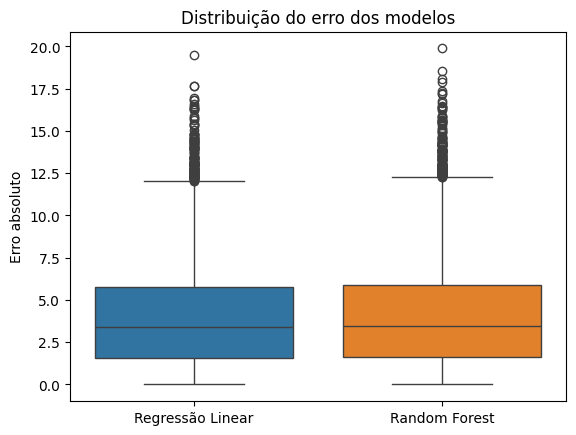

In [35]:
import seaborn as sns
import pandas as pd

erro_linear = abs(y_test - previsoes_linear)
erro_arvore = abs(y_test - previsoes_arvore)

df_erros = pd.DataFrame({
    "Regressão Linear": erro_linear,
    "Random Forest": erro_arvore
})

sns.boxplot(data=df_erros)

plt.ylabel("Erro absoluto")
plt.title("Distribuição do erro dos modelos")

plt.show()

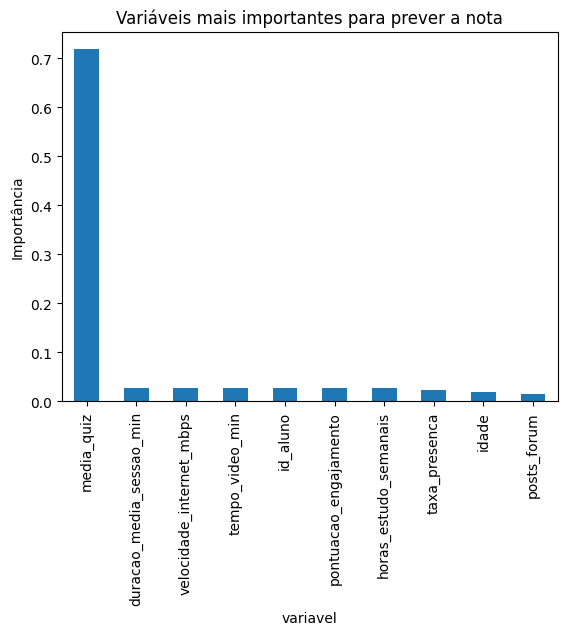

In [38]:
import pandas as pd

importances = modelo_arvore.feature_importances_

df_importancia = pd.DataFrame({
    "variavel": X_train.columns,
    "importancia": importances
}).sort_values("importancia", ascending=False)

df_importancia.head(10).plot.bar(x="variavel", y="importancia", legend=False)

plt.title("Variáveis mais importantes para prever a nota")
plt.ylabel("Importância")

plt.show()

Qual modelo foi melhor? Vamos avaliar usando o **MAE (Mean Absolute Error — Erro Absoluto Médio)**, que nos diz, em média, por quantos pontos nosso modelo errou a nota do aluno.

In [24]:
erro_linear = mean_absolute_error(y_test, previsoes_linear)
erro_arvore = mean_absolute_error(y_test, previsoes_arvore)

print(f"A Regressão Linear errou a nota, em média, por: {erro_linear:.2f} pontos")
print(f"O Random Forest errou a nota, em média, por: {erro_arvore:.2f} pontos")

# O Random Forest costuma ser bem mais preciso que a Regressão Linear, 
# mas os dois são ótimos exemplos práticos.

A Regressão Linear errou a nota, em média, por: 3.99 pontos
O Random Forest errou a nota, em média, por: 4.07 pontos



## 3. Mão na Massa 02: Classificação
Agora vamos mudar a abordagem. Não queremos mais saber a *nota exata*, queremos saber a pessoa vai ou não desistir?

In [ ]:

# Agora nossa variável alvo é a categoria 'y_class = df['abandono']
'
y_class = df['abandono']

# E as variáveis preditoras são as mesmas, 
# mas temos que retirar a 'Nota_na_Prova' para não dar a resposta de bandeja pro modelo!
X_class = df.drop(columns=['nota_final', 'genero', 'pais','tipo_dispositivo', 'abandono'])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

In [42]:
# Treinando um Classificador Random Forest
modelo_classificador = RandomForestClassifier(random_state=42)
modelo_classificador.fit(X_train_c, y_train_c)

# Fazendo previsões
previsoes_class = modelo_classificador.predict(X_test_c)

# Avaliando com Acurácia (Porcentagem de acertos)
acuracia = accuracy_score(y_test_c, previsoes_class)
print(f"O modelo acertou {acuracia * 100:.1f}% das classificações (abandono/não abandono)!")

O modelo acertou 100.0% das classificações (abandono/não abandono)!


A **Matriz de Confusão** é a melhor forma de visualizar os erros e acertos de um modelo de classificação:

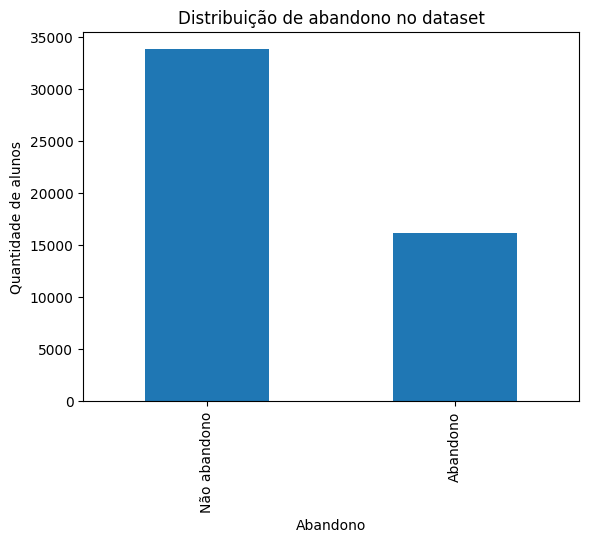

In [44]:
df['abandono'].value_counts().plot(
    kind='bar'
)

plt.title("Distribuição de abandono no dataset")
plt.xlabel("Abandono")
plt.ylabel("Quantidade de alunos")

plt.xticks([0,1], ['Não abandono','Abandono'])

plt.show()

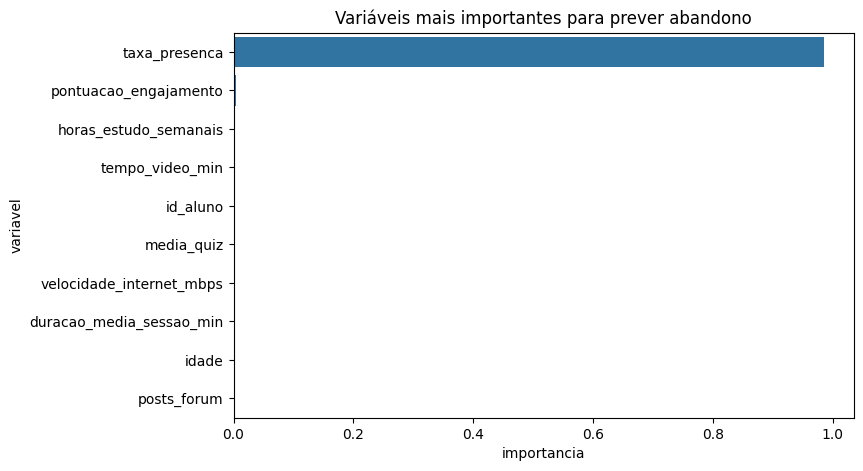

In [45]:
importances = modelo_classificador.feature_importances_

df_importancia = pd.DataFrame({
    "variavel": X_train_c.columns,
    "importancia": importances
}).sort_values("importancia", ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_importancia.head(10),
    x="importancia",
    y="variavel"
)

plt.title("Variáveis mais importantes para prever abandono")

plt.show()

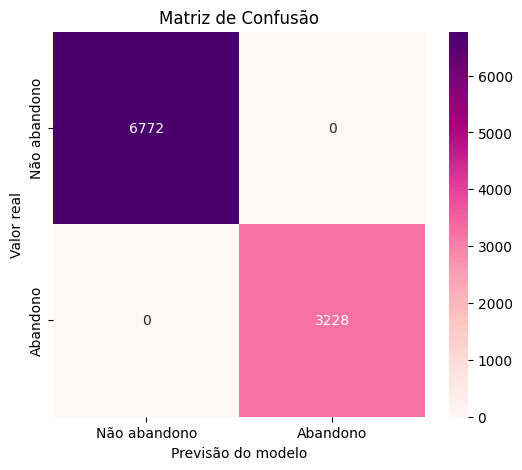

In [43]:
plt.figure(figsize=(6,5))

sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='RdPu',
    xticklabels=['Não abandono','Abandono'],
    yticklabels=['Não abandono','Abandono']
)

plt.title("Matriz de Confusão")
plt.xlabel("Previsão do modelo")
plt.ylabel("Valor real")

plt.show()